## Read data and plot images

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()
case = path.split("\\")[-1]
print(path, case)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
D:\Promotion\neurolib\GUI\gui\data\000001 000001


In [2]:
def set_target_init(exc_, inh_, max_I):
    
    initVars_ = [None] * len(exc_)
    target_ = [None] * len(exc_)
    
    for i in range(len(exc_)):
        print("------- ", i, exc_[i], inh_[i])
        aln.params.ext_exc_current = exc_[i]
        aln.params.ext_inh_current = inh_[i]

        aln.params.duration = 3000.

        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = max_I[0])
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = max_I[1])
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars_[i] = init_state_vars

        aln.params.duration = dur
        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]
    
    return initVars_, target_

In [3]:
data_array = data.read_data(path, case)
exc_, inh_, no_c_, both_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4 = data_array[12:]

with open(path + '/bistability_exc_inh_' + str(case) + '.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc = load_array[0]
ext_inh = load_array[1]

[bestControl_init, costnode_init, weights_init, bestControl_0, costnode_0, weights_0] = data.read_control(path, case)

dur = 100
dur_pre = 10
dur_post = 10

trans_time = 0.8

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.] 

-------  0 3.65 7.4
-------  1 2.799999999999997 2.55
-------  2 3.149999999999996 2.75
-------  3 3.099999999999996 2.9499999999999997
-------  4 2.999999999999997 3.15
-------  5 2.3000000000000003 3.5999999999999996
-------  6 2.4499999999999997 4.75
D:\Promotion\neurolib\GUI\gui\plots_\000001\1
0 0
3.65 3.65 7.4 7.4
0
1 0
2.799999999999997 3.65 2.55 7.4
1 388
2.799999999999997 2.799999999999997 2.55 2.55
388
2 0
3.149999999999996 3.65 2.75 7.4
2 388
3.149999999999996 2.799999999999997 2.75 2.55
2 485
3.149999999999996 3.149999999999996 2.75 2.75
485
3 0
3.099999999999996 3.65 2.9499999999999997 7.4
3 388
3.099999999999996 2.799999999999997 2.9499999999999997 2.55
3 485
3.099999999999996 3.149999999999996 2.9499999999999997 2.75
3 582
3.099999999999996 3.099999999999996 2.9499999999999997 2.9499999999999997
582
4 0
2.999999999999997 3.65 3.15 7.4
4 388
2.999999999999997 2.799999999999997 3.15 2.55
4 485
2.999999999999997 3.149999999999996 3.15 2.75
4 582
2.999999999999997 3.09999999

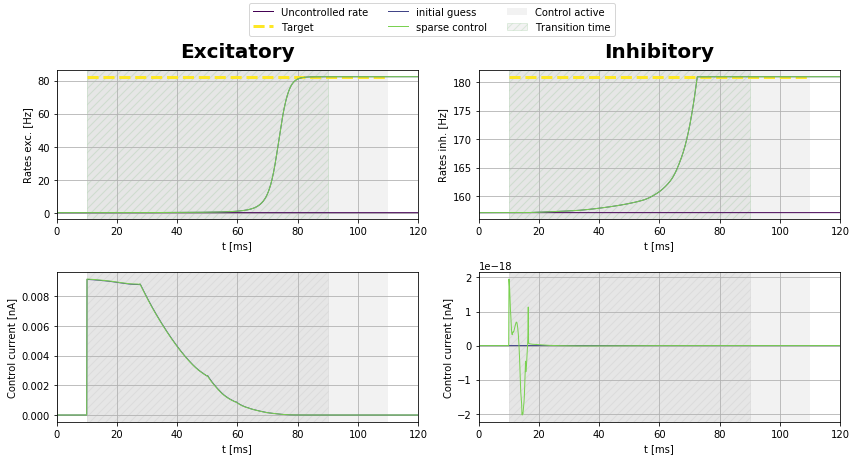

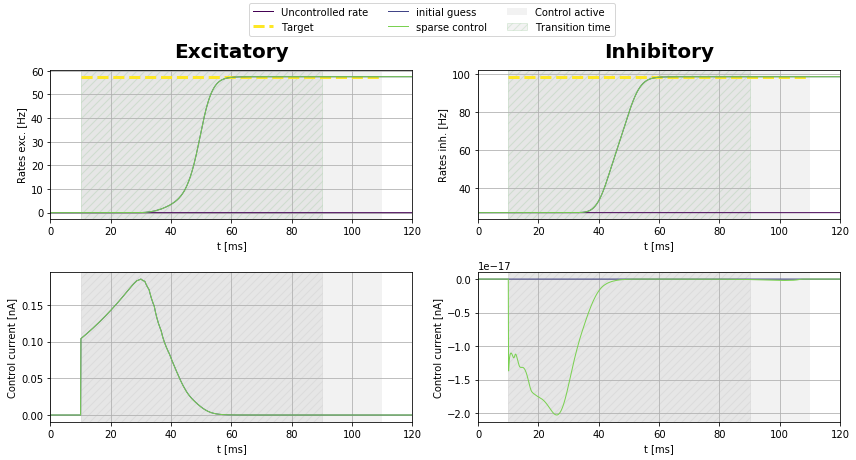

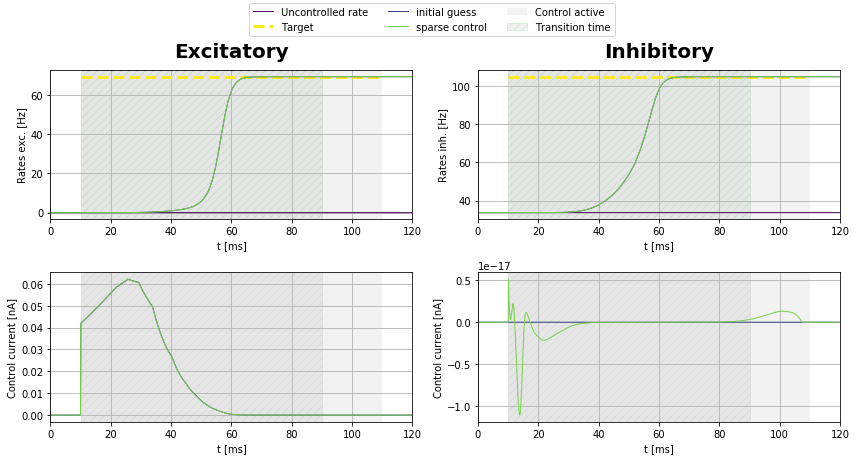

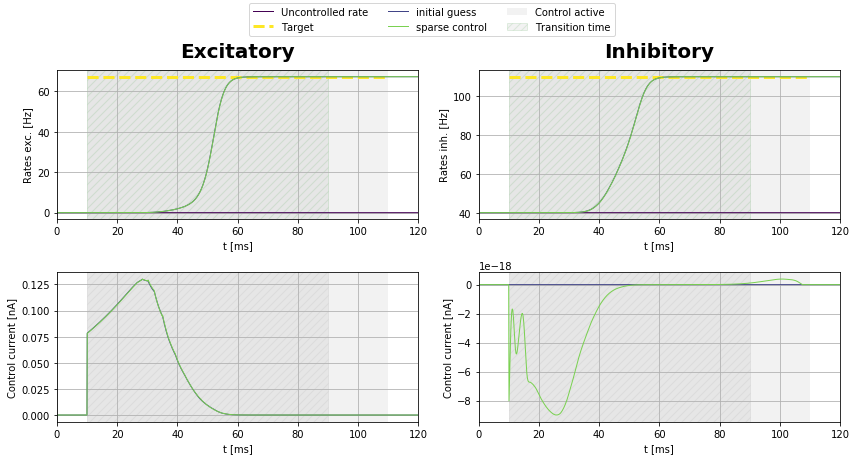

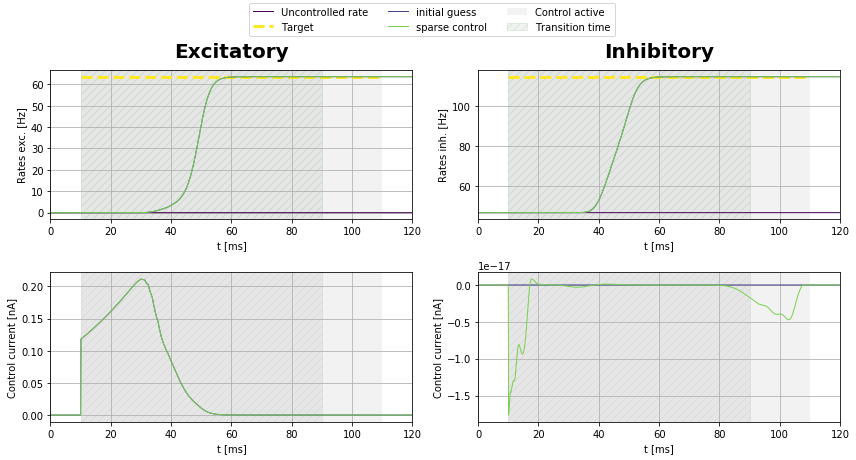

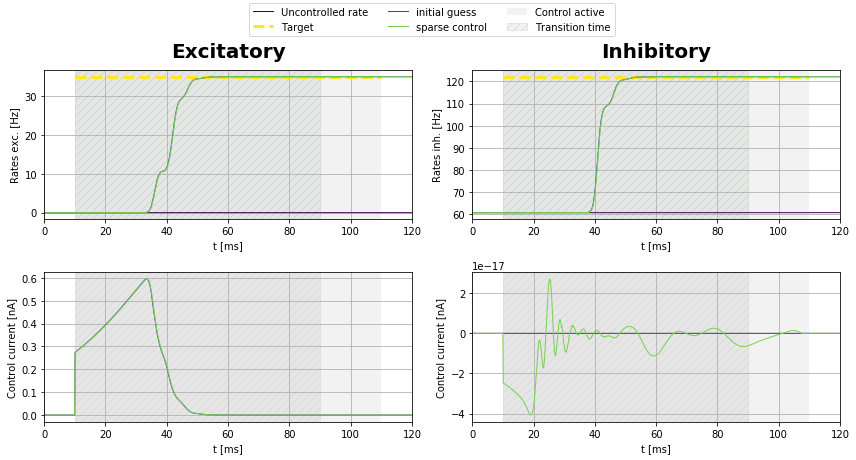

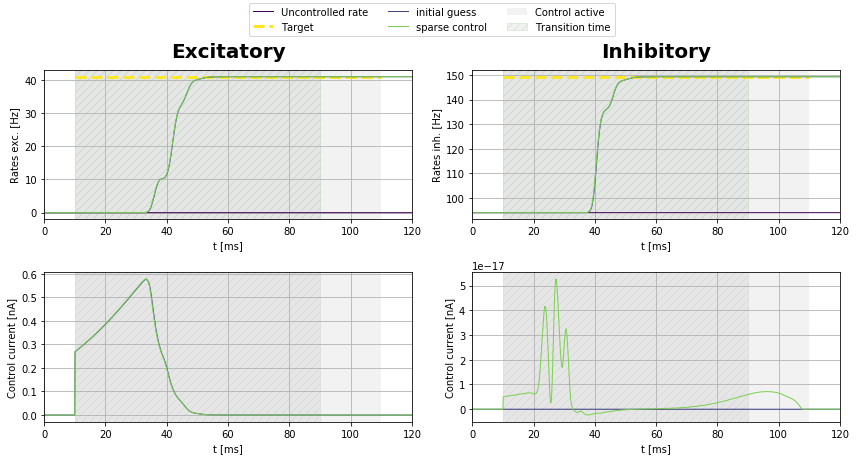

In [5]:
initVars_1, target_1 = set_target_init(exc_1, inh_1, max_I)

path1 = path.split("\\data")[0] + '\\plots_\\' + case + '\\1'
print(path1)

for i in range(len(exc_1)):
    file_ = str(i)
    aln.params.ext_exc_current = exc_1[i]
    aln.params.ext_inh_current = inh_1[i]
    
    for j in range(len(ext_exc)):
        if j in exc_:
            print(i, j)
            print(exc_1[i],ext_exc[j],inh_1[i],ext_inh[j])
            if exc_1[i] == ext_exc[j] and inh_1[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_1[i], target_1[i], path1, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

-------  0 2.1499999999999995 2.0
-------  1 2.4999999999999982 2.2
-------  2 2.05 2.4
-------  3 2.699999999999998 3.35
D:\Promotion\neurolib\GUI\gui\plots_\000001\2
0 0
0 388
0 485
0 582
0 679
0 873
0 970
1 0
1 388
1 485
1 582
1 679
1 873
1 970
2 0
2 388
2 485
2 582
2 679
2 873
2 970
3 0
3 388
3 485
3 582
3 679
3 873
3 970


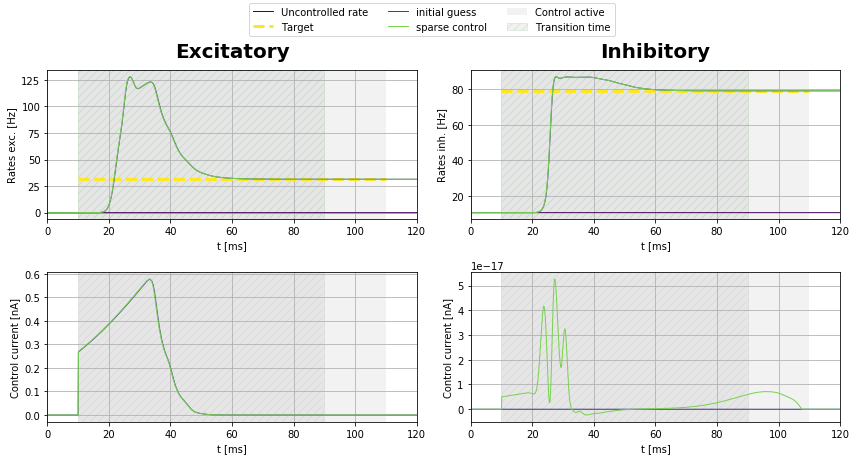

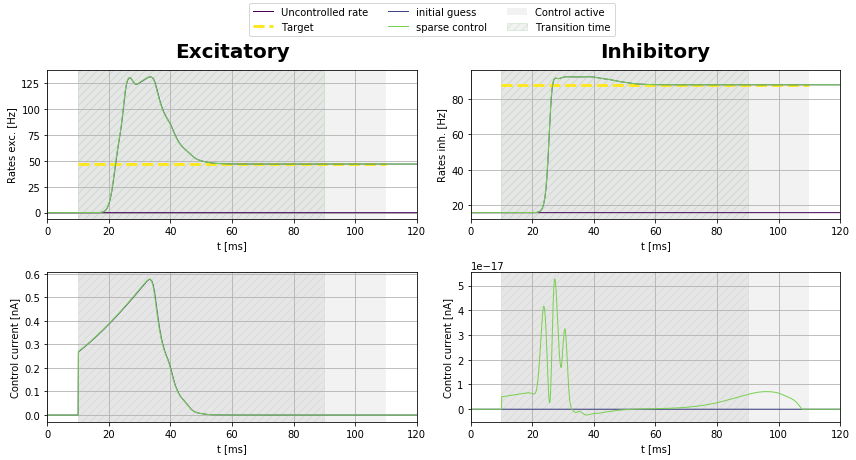

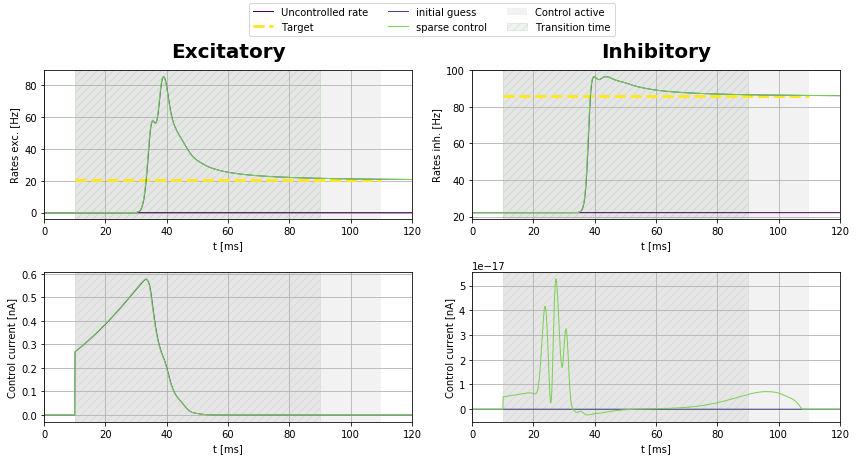

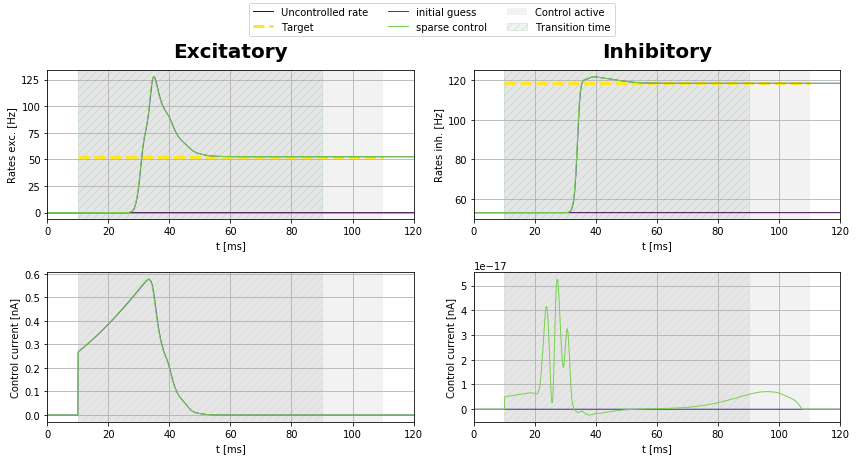

In [6]:
initVars_2, target_2 = set_target_init(exc_2, inh_2, max_I)

path2 = path.split("\\data")[0] + '\\plots_\\' + case + '\\2'
print(path2)

for i in range(len(exc_2)):
    file_ = str(i)
    aln.params.ext_exc_current = exc_2[i]
    aln.params.ext_inh_current = inh_2[i]
    
    for j in range(len(ext_exc)):
        if j in exc_:
            print(i, j)
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_2[i], target_2[i], path2, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

In [7]:
initVars_3, target_3 = set_target_init(exc_3, inh_3, max_I)

path3 = path.split("\\data")[0] + '\\plots_\\' + case + '\\3'
print(path3)

for i in range(len(exc_3)):
    file_ = str(i)
    aln.params.ext_exc_current = exc_3[i]
    aln.params.ext_inh_current = inh_3[i]
    
    for j in range(len(ext_exc)):
        if j in exc_:
            print(i, j)
            if exc_3[i] == ext_exc[j] and inh_3[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_3[i], target_3[i], path3, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\gui\plots_\000001\3


In [8]:
initVars_4, target_4 = set_target_init(exc_4, inh_4, max_I)

path4 = path.split("\\data")[0] + '\\plots_\\' + case + '\\4'
print(path4)

for i in range(len(exc_4)):
    file_ = str(i)
    aln.params.ext_exc_current = exc_4[i]
    aln.params.ext_inh_current = inh_4[i]
    
    for j in range(len(ext_exc)):
        if j in exc_:
            print(i, j)
            if exc_4[i] == ext_exc[j] and inh_4[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
                
    print(np.amin(bestControl_0[index_][0,1,:]), np.amax(bestControl_0[index_][0,1,:]))
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_4[i], target_4[i], path4, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\gui\plots_\000001\4
